# Sinkhorn-HTI

An entropic substitute for the inner-loop $c$-transform in HTI
(Amad & van der Schaar, ICLR 2026). ENSAE Optimal Transport course
project, 2026.

The notebook reimplements HTI on the semicircles benchmark of §5.1
and replaces the Kantorovich $c$-transform's inner L-BFGS minimization
by the closed-form soft $c$-transform from entropic OT. The two
variants are compared at matched seed and training budget.


## Overview

HTI trains a conditional Lagrangian-OT surrogate by alternating
between a Kantorovich semi-dual step and an outer metric update.
Inside the semi-dual, the $c$-transform has to be solved per source
point in the mini-batch, which HTI does with a short L-BFGS run
(Algorithm 1, line 10). Adding entropic regularization makes that
inner problem closed-form: the soft $c$-transform reduces it to one
LogSumExp over the mini-batch, and the map-regression target becomes
the entropic barycentric projection of Pooladian & Niles-Weed (2021).
We compare both variants on the semicircles benchmark.

## Setup


In [1]:
import os, sys
from pathlib import Path

import jax, jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

jax.config.update("jax_platform_name", "cpu")

REPO = Path(os.getcwd())
FOLDER = REPO / "sinkhorn-hti"
if str(FOLDER) not in sys.path:
    sys.path.insert(0, str(FOLDER))

FIG_DIR = REPO / "report" / "figs"
RUNS_DIR = FOLDER / "runs"
for d in (FIG_DIR, RUNS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Seed selected as the best of five exploratory seeds at n_outer=400.
SEED = 5

## HTI on semicircles


### Data

For each condition $c \in \{1, 2, 3, 4\}$ and
time $t \in [0, 1]$, a sample is generated by

$$
\begin{aligned}
y \;&=\; \bigl(x_{\text{off}}(c),\, 0\bigr) + R\,\bigl(\cos\Phi,\, \sin\Phi\bigr), \\
R \;&\sim\; \mathrm{LogNormal}(0,\, \sigma_r^2), \\
\Phi \;&\sim\; \mathrm{VonMises}\bigl(\mu_\Phi(c, t),\, \kappa\bigr).
\end{aligned}
$$

with $x_{\text{off}}(c) \in \{-1, -1, +1, +1\}$,
$\mu_\Phi(c, t) \in \{t\pi, -t\pi, (1{-}t)\pi, (t{-}1)\pi\}$,
$\sigma_r = 0.05$, and $\kappa = 5$. Anchors are observed at
$t \in \{0, 0.5, 1\}$; the held-out evaluation points are $t \in
\{0.25, 0.75\}$. We draw 100 samples per condition at each anchor
time.


In [2]:
from sinkhorn_hti.data.semicircles import (
    SEMICIRCLE_TIMES, SEMICIRCLE_CONDITIONS, sample_anchors,
)

key = jax.random.PRNGKey(SEED)
data = sample_anchors(n_per_condition=100, anchor_times=SEMICIRCLE_TIMES, key=key)
print({t: {c: y.shape for c, y in by_c.items()} for t, by_c in data.items()})


{0.0: {1: (100, 2), 2: (100, 2), 3: (100, 2), 4: (100, 2)}, 0.5: {1: (100, 2), 2: (100, 2), 3: (100, 2), 4: (100, 2)}, 1.0: {1: (100, 2), 2: (100, 2), 3: (100, 2), 4: (100, 2)}}


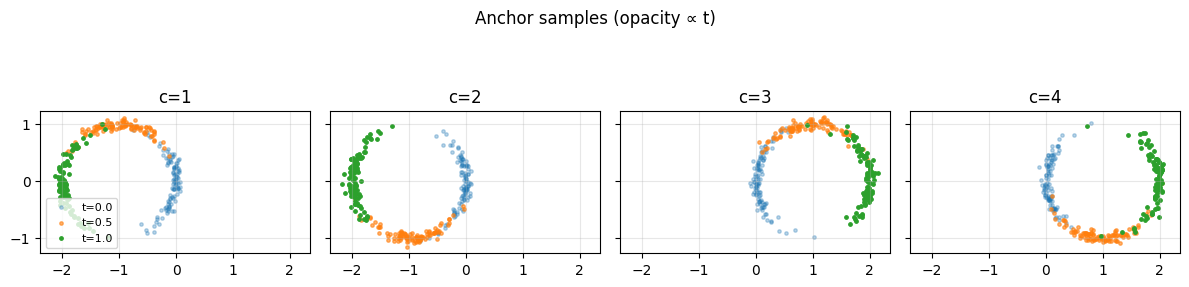

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3), sharex=True, sharey=True)
for ax, c in zip(axes, SEMICIRCLE_CONDITIONS):
    for t, a in zip(SEMICIRCLE_TIMES, [0.3, 0.6, 1.0]):
        ys = np.asarray(data[t][c])
        ax.scatter(ys[:, 0], ys[:, 1], s=6, alpha=a, label=f"t={t}")
    ax.set_title(f"c={c}"); ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
axes[0].legend(loc="lower left", fontsize=8)
fig.suptitle("Anchor samples (opacity ∝ t)", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "anchors.pdf", bbox_inches="tight")
plt.show()


### Lagrangian cost

For adjacent anchor distributions at condition $x$, HTI defines the
cost from a source $y_0$ to a target $y_1$ as the smallest action
of any path connecting them:

$$
\begin{aligned}
c(y_0, y_1 \mid x) \;&=\; \inf_{q \,:\, q(0) = y_0,\, q(1) = y_1} \int_0^1 \mathcal{L}(q, \dot q \mid x)\, ds, \\
\mathcal{L} \;&=\; \tfrac12\, \dot q^\top G_{\theta_G}(q \mid x)\, \dot q \;-\; \widehat U(q \mid x).
\end{aligned}
$$

The kinetic term $\tfrac12 \dot q^\top G \dot q$ measures arc
length in a Riemannian metric $G$, which depends on the position
$q$ and is learned during training. The potential $\widehat U$ is a
per-condition kernel-density estimate over the anchor samples,
scaled by $\alpha$; it pulls paths toward dense regions of the data.

The metric $G$ is parametrized as $R D R^\top$, with $R$ a product
of Givens rotations and $D$ a diagonal whose entries are
softmax-normalized; this keeps $G$ positive-definite and bounds its
condition number. Candidate paths are cubic splines pinned at $y_0$
and $y_1$, with interior control points predicted by a small
conditional MLP $S_{\theta_S}(y_0, y_1, x)$. With $G$ and $S$
fixed, the cost $c(y_0, y_1 \mid x)$ is then a deterministic
integral of $\mathcal{L}$ along the predicted path.

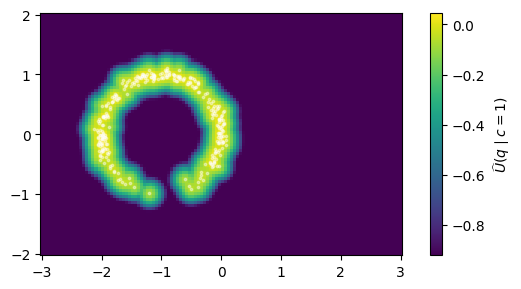

In [4]:
from sinkhorn_hti.lagrangian import stack_obs_per_condition, potential_U

conds = SEMICIRCLE_CONDITIONS
ys_per_c = stack_obs_per_condition(data, conditions=conds)
# Heatmap of U(.|c=1) on a grid.
alpha, h_y = 0.05, 0.05
xs = np.linspace(-3, 3, 120); ys = np.linspace(-2, 2, 80)
XX, YY = np.meshgrid(xs, ys)
Q = jnp.asarray(np.stack([XX.ravel(), YY.ravel()], axis=-1))
U_vals = jax.vmap(lambda q: potential_U(q, ys_per_c[0], h_y, alpha))(Q)
UU = np.asarray(U_vals).reshape(XX.shape)

fig, ax = plt.subplots(figsize=(6, 3))
im = ax.pcolormesh(XX, YY, UU, shading="auto", cmap="viridis")
ax.scatter(np.asarray(ys_per_c[0])[:, 0], np.asarray(ys_per_c[0])[:, 1],
           s=3, color="white", alpha=0.4)
fig.colorbar(im, ax=ax, label=r"$\widehat U(q\mid c{=}1)$")
ax.set_aspect("equal")
fig.tight_layout(); plt.show()


Heatmap of $\widehat U(q \mid c{=}1)$ on a 2D grid, with anchor
samples overlaid in white. Bright regions are high density (with
$\widehat U$ close to $0$); dark regions are low density. Paths through
bright regions have lower action so that geodesics get pulled into the
data manifold.

### Kantorovich semi-dual

Kantorovich duality rewrites
$\mathrm{OT}_c(\mu, \nu) = \inf_{\pi \in \Pi(\mu, \nu)} \int c \, d\pi$
as a single-potential supremum:

$$
\begin{aligned}
\mathrm{OT}_c(\mu, \nu) \;&=\; \sup_{g} \Bigl\{ \int g^c(y_0)\, d\mu(y_0) + \int g(y_1)\, d\nu(y_1) \Bigr\}, \\
g^c(y_0) \;&:=\; \inf_{y_1 \in \mathbb{R}^d} \bigl\{ c(y_0, y_1) - g(y_1) \bigr\}.
\end{aligned}
$$

Evaluating $g^c$ requires, for every source $y_0$ in a mini-batch,
an inner minimization over $y_1$. With $c$ and $g$ both parametrized
by neural networks, this problem is non-convex; HTI solves it with a
short L-BFGS run, warm-started from a transport-map network
$T_{\theta_T}(y_0 \mid x)$ that is itself trained to track the
resulting argmin. The inner argmin is held
fixed when computing the outer gradients, so
only $g$ is differentiated.

In [5]:
from sinkhorn_hti.ctransform import lbfgs_ctransform
from sinkhorn_hti.config import LBFGSInnerConfig

# Unit test: optimum 5 units away from warm start -> L-BFGS still converges.
def g_fn(y): return jnp.zeros(())
def c_fn(y0, y1): return 0.5 * jnp.sum((y1 - y0 - 5.0) ** 2)

y0 = jnp.zeros((4, 2))
y_star, ct, grad_norms = lbfgs_ctransform(
    y0, y0, g_fn, c_fn, LBFGSInnerConfig(maxiter=20),
)
print("y_star:", np.asarray(y_star))
print("expected ~ 5.0, max err:", float(jnp.max(jnp.abs(y_star - 5.0))))
print("||grad||_inf at final iterate:", float(grad_norms.max()))


y_star: [[5. 5.]
 [5. 5.]
 [5. 5.]
 [5. 5.]]
expected ~ 5.0, max err: 0.0
||grad||_inf at final iterate: 0.0


### Training

HTI's training (Algorithm 1) is a nested loop: each outer iteration
runs several inner passes that update the potential, transport map,
and spline against the dual, map, and path losses, then takes one
outer step on the metric. The headline runs are precomputed and
cached, loaded here.

In [6]:
from sinkhorn_hti.runs import load_headline

In [7]:
payload_lbfgs = load_headline("lbfgs")
logs_lbfgs = payload_lbfgs["logs"]


### Sampling

For target time $t^\star$ and condition $x$: draw $y_k$ from the
nearest observed anchor, push it to $y_{k+1}=T_{\theta_T,k}(y_k\mid x)$,
fit the spline geodesic with control points
$S_{\theta_S}(y_k,y_{k+1},x)$, and evaluate at
$s^\star=(t^\star-t_k)/(t_{k+1}-t_k)$.


In [8]:
from sinkhorn_hti.lagrangian import cubic_spline_eval

def _single_trajectory(comps, y0, x, anchor_times, ts):
    n_int = len(anchor_times) - 1
    endpoints = [y0]
    for k in range(n_int):
        endpoints.append(comps.maps[k](endpoints[-1], x))
    pts = []
    for t in ts:
        k = 0
        while k < n_int - 1 and t > anchor_times[k + 1]:
            k += 1
        s = 0.0 if anchor_times[k + 1] == anchor_times[k] else (
            (t - anchor_times[k]) / (anchor_times[k + 1] - anchor_times[k])
        )
        ctrl = comps.spline(endpoints[k], endpoints[k + 1], x)
        q, _ = cubic_spline_eval(ctrl, jnp.asarray([float(s)]))
        pts.append(np.asarray(q[0]))
    return np.stack(pts, axis=0)

def _trajectory_grid(comps, data_local, n_traces=12, n_t=25):
    anchors = sorted(data_local.keys())
    ts = np.linspace(0.0, 1.0, n_t)
    rng = np.random.default_rng(0)
    traces_by_c = {}
    for c in SEMICIRCLE_CONDITIONS:
        pool = np.asarray(data_local[anchors[0]][c])
        idx = rng.choice(pool.shape[0], n_traces, replace=False)
        starts = pool[idx]
        x = jnp.asarray([float(c)])
        trajs = np.stack(
            [_single_trajectory(comps, jnp.asarray(y0), x, anchors, ts) for y0 in starts],
            axis=0,
        )
        traces_by_c[c] = trajs
    return ts, traces_by_c

ts, traces_lbfgs = _trajectory_grid(payload_lbfgs["comps"], payload_lbfgs["data"])


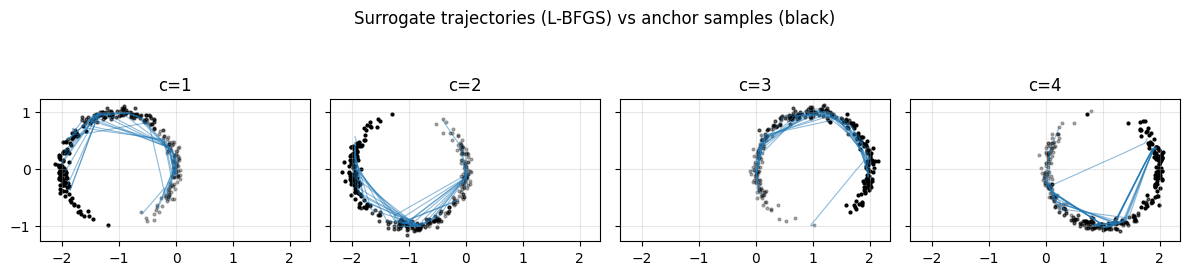

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3), sharex=True, sharey=True)
for ax, c in zip(axes, SEMICIRCLE_CONDITIONS):
    traces = traces_lbfgs[c]
    for traj in traces:
        ax.plot(traj[:, 0], traj[:, 1], color="C0", alpha=0.5, lw=0.8)
    for t, a in zip(SEMICIRCLE_TIMES, [0.3, 0.6, 1.0]):
        ys = np.asarray(payload_lbfgs["data"][t][c])
        ax.scatter(ys[:, 0], ys[:, 1], s=4, alpha=a, color="k")
    ax.set_title(f"c={c}"); ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
fig.suptitle("Surrogate trajectories (L-BFGS) vs anchor samples (black)")
fig.tight_layout()
fig.savefig(FIG_DIR / "figure1d_lbfgs.pdf", bbox_inches="tight")
plt.show()


## Entropic substitution

### Soft $c$-transform and barycentric target

The entropic dual of the OT primal has a closed-form first-order
condition in $f$ at fixed $g$, the soft $c$-transform

$$
g^{c,\varepsilon}(y_0) \;=\; -\varepsilon \log\!\int
    \exp\!\bigl((g(y_1) - c(y_0, y_1))/\varepsilon\bigr)\, d\nu(y_1),
$$

with $g^{c,\varepsilon} \to g^c$ as $\varepsilon \to 0$. On a
$B$-sample mini-batch the integral becomes a LogSumExp, replacing
HTI's inner L-BFGS run by one closed-form evaluation per source
$y_0$. The transport-map regression target correspondingly becomes
the entropic barycentric projection of Pooladian & Niles-Weed (2021),

$$
\begin{aligned}
\widehat T^\varepsilon(y_0) \;&=\; \sum_{j=1}^B w_j(y_0)\, y_1^{(j)}, \\
w_j(y_0) \;&\propto\; \exp\!\bigl((g(y_1^{(j)}) - c(y_0, y_1^{(j)}))/\varepsilon\bigr),
\end{aligned}
$$

which recovers the hard argmin as $\varepsilon \to 0$. Everything
else in the training loop is unchanged.

### Headline

Both variants run on the HTI papers budget, with L-BFGS at
$\text{maxiter}=10$ and Sinkhorn-HTI at $\varepsilon=3\!\times\!10^{-3}$.

### Hyperparameters

The exact configuration we run for both variants

| Component | Value | Source |
|---|---|---|
| Outer iterations $N_\text{outer}$ | $2001$ | Table 8 |
| Inner iterations $N_\text{inner}$ | $10$ | Table 8 |
| L-BFGS iterations | $10$ | Table 8 |
| Mini-batch $B$ | $64$ | release: $1024$ |
| Lagrangian $(\alpha, h_y)$ | $(0.05, 0.05)$ | Table 8 |
| Entropic $\varepsilon$ (Sinkhorn-HTI only) | $3\times 10^{-3}$ | chosen |
| Spline MLP | $[512, 512]$ | Table 8: $[1024, 1024]$ |
| $g, T$ MLPs | $[64, 64, 64, 64]$ | Table 8 |
| Metric MLP | $[128, 128]$ | Table 8 |
| Spline knots | $15$ | Table 8 |
| FiLM width | $16$ | Table 8 |
| Eigenvalue trace budget $B_E$ | $2$ | Table 8 |
| Eigenvalue floor $\lambda_\text{min}$ | $0.3$ | release: $0.1$; paper: none |
| Adam learning rate $\eta_{g,T,S}$ | $10^{-4}$ | Table 8 |
| Outer learning rate $\eta_G$ | $5\times 10^{-4}$ | Table 8: $5\times 10^{-3}$ |
| Gradient clip | $0.25$ | release: $1.0$ |
| KDE stabilizer $\varepsilon_\text{den}$ | $10^{-8}$ | chosen |

In [10]:
payload_ent = load_headline("entropic")
logs_ent = payload_ent["logs"]

from sinkhorn_hti.metrics import evaluate_semicircles


def _mean_metrics(payload):
    res = evaluate_semicircles(payload["comps"], payload["data"])
    nll = sum(v[0] for v in res.values()) / len(res)
    cd = sum(v[1] for v in res.values()) / len(res)
    return nll, cd, payload["logs"][-1]["wall_s"]


nll_l, cd_l, t_l = _mean_metrics(payload_lbfgs)
nll_e, cd_e, t_e = _mean_metrics(payload_ent)

print(f"{'method':<12s} {'NLL':>8s} {'CD':>8s} {'train_s':>9s}")
print(f"{'L-BFGS':<12s} {nll_l:>8.2f} {cd_l:>8.4f} {t_l:>9.0f}")
print(f"{'entropic':<12s} {nll_e:>8.2f} {cd_e:>8.4f} {t_e:>9.0f}")
print(f"{'ratio':<12s} {'':>8s} {'':>8s} {t_l/t_e:>9.2f}x")

method            NLL       CD   train_s
L-BFGS           6.98   0.0158     12461
entropic        12.05   0.0130      3808
ratio                               3.27x


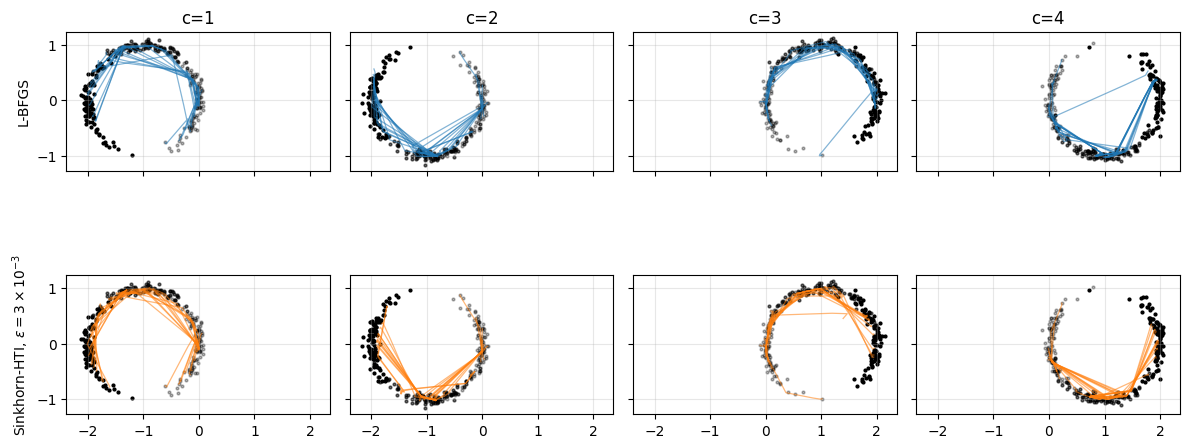

In [11]:
ts_cmp, traces_ent = _trajectory_grid(payload_ent["comps"], payload_ent["data"])

fig, axes = plt.subplots(2, 4, figsize=(12, 6), sharex=True, sharey=True)
row_data = [
    ("L-BFGS", "C0", payload_lbfgs["data"], traces_lbfgs),
    (r"Sinkhorn-HTI, $\varepsilon=3\times 10^{-3}$", "C1",
     payload_ent["data"], traces_ent),
]
for row, (label, color, data_r, traces_r) in enumerate(row_data):
    for ax, c in zip(axes[row], SEMICIRCLE_CONDITIONS):
        for traj in traces_r[c]:
            ax.plot(traj[:, 0], traj[:, 1], color=color, alpha=0.55, lw=0.9)
        for t, a in zip(SEMICIRCLE_TIMES, [0.3, 0.6, 1.0]):
            ys = np.asarray(data_r[t][c])
            ax.scatter(ys[:, 0], ys[:, 1], s=4, alpha=a, color="k")
        ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
        if row == 0: ax.set_title(f"c={c}")
    axes[row, 0].set_ylabel(label)
fig.tight_layout()
fig.savefig(FIG_DIR / "trajectories_compare.pdf", bbox_inches="tight")
plt.show()

### Training dynamics

We log four losses per outer iteration: the semi-dual (maximised
in $g$, minimised in $G$), the map MSE (minimised in $T$ against the
$c$-transform argmin), the path loss (minimised in $S$), and the
outer metric loss (the semi-dual at the current $(g, T, S)$)

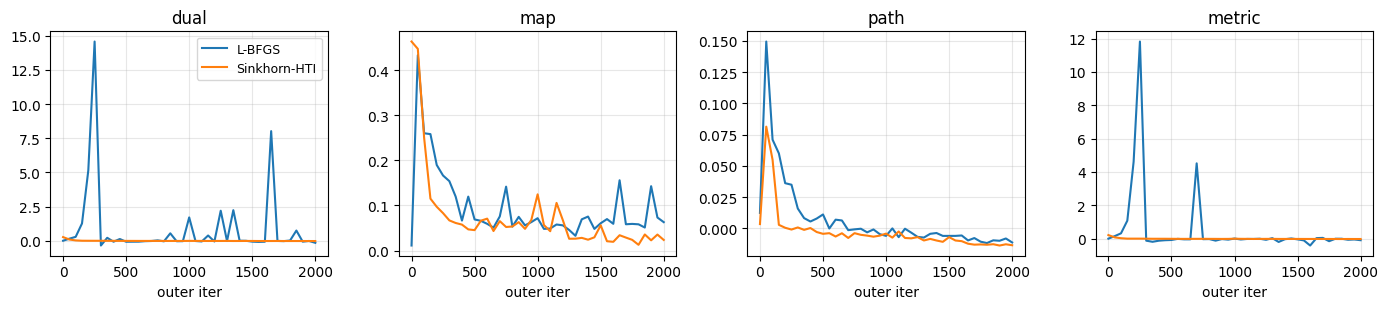

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), sharex=True)
for ax, k in zip(axes, ["dual", "map", "path", "metric"]):
    for logs_list, label, color in [(logs_lbfgs, "L-BFGS", "C0"),
                                    (logs_ent,   "Sinkhorn-HTI", "C1")]:
        outer = [e["outer"] for e in logs_list]
        ax.plot(outer, [e[k] for e in logs_list], label=label, color=color)
    ax.set_title(k); ax.set_xlabel("outer iter"); ax.grid(alpha=0.3)
axes[0].legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "training_curves.pdf", bbox_inches="tight")
plt.show()

L-BFGS' dual and metric panels show isolated spikes:
a metric update can flip which basin of $c - g$ the inner iterates
settle into, and the per-sample value jumps when that happens.
Sinkhorn-HTI is smooth in the parameters through the LogSumExp, so
it has no such spikes.

### Discussion

The two methods share everything except the inner solver, so any held-out gap is attributable to the substitution.

The entropic step is one LogSumExp over a pre-built cost matrix;
L-BFGS does $B$ independent runs of 10 iterations each. The
substitution thus saves roughly an order of magnitude in per-mini-batch
evaluations.

At fixed $\varepsilon>0$ the entropic OT value carries an
$\mathcal{O}(\varepsilon)$ bias (Pal 2024).